In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Cấu hình để vẽ biểu đồ hiển thị được tiếng Việt và đẹp mắt hơn
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"  # Hoặc font hệ thống hỗ trợ tiếng Việt
plt.rcParams["figure.figsize"] = (12, 6)

# ĐỌC DỮ LIỆU
df = pd.read_csv("VN_housing_dataset.csv")

# ==========================================
# BƯỚC XỬ LÝ DỮ LIỆU (DATA CLEANING)
# ==========================================

# Loại bỏ các dòng khuyết thiếu ở các cột cốt lõi phục vụ phân tích
df = df.dropna(subset=["Giá/m2", "Quận", "Ngày", "Diện tích"])

# Hàm chuẩn hóa cột Giá/m2 về dạng số (đơn vị: triệu VND/m2)
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = (
        str(price_str)
        .lower()
        .strip()
        .replace('"', "")
        .replace(" ", "")
    )

    # Thay thế dấu phẩy thành dấu chấm để chuyển sang float (ví dụ: 91,67 -> 91.67)
    price_str = price_str.replace(",", ".")

    try:
        if "triệu/m²" in price_str:
            return float(price_str.replace("triệu/m²", ""))
        elif "tỷ/m²" in price_str:
            return (
                float(price_str.replace("tỷ/m²", "")) * 1000
            )  # Đổi tỷ sang triệu
        else:
            # Trường hợp chỉ có số
            return float(price_str)
    except:
        return np.nan


# Áp dụng hàm xử lý giá
df["Gia_Trieu_m2"] = df["Giá/m2"].apply(clean_price)

# Chuẩn hóa cột Diện tích (bỏ chữ m² và chuyển về dạng số)
df["Dien_Tich_Numeric"] = (
    df["Diện tích"]
    .astype(str)
    .str.replace(" m²", "")
    .str.replace("m²", "")
    .str.strip()
    .str.replace(",", ".")
)
df["Dien_Tich_Numeric"] = pd.to_numeric(
    df["Dien_Tich_Numeric"], errors="coerce"
)

# Chuyển đổi cột Ngày sang datetime
df["Datetime"] = pd.to_datetime(df["Ngày"], errors="coerce")
df["Nam"] = df["Datetime"].dt.year
df["Thang"] = df["Datetime"].dt.month

# Loại bỏ các giá trị dị biệt (Outliers) quá vô lý để biểu đồ không bị méo mó
# Ví dụ: Giá > 1 tỷ/m2 hoặc diện tích quá nhỏ/quá lớn do nhập sai
df = df[(df["Gia_Trieu_m2"] > 5) & (df["Gia_Trieu_m2"] < 1000)]
df = df[(df["Dien_Tich_Numeric"] > 10) & (df["Dien_Tich_Numeric"] < 1000)]

# Điền giá trị thiếu cho cột 'Giấy tờ pháp lý' thành 'Chưa xác định' để phân tích
df["Giấy tờ pháp lý"] = df["Giấy tờ pháp lý"].fillna("Chưa xác định")

# Xử lý cột 'Số phòng ngủ' (Ví dụ: "5 phòng" -> 5)
df["Phong_Ngu_Numeric"] = (
    df["Số phòng ngủ"]
    .astype(str)
    .str.extract(r"(\d+)")
)  # Trích xuất các chữ số
df["Phong_Ngu_Numeric"] = pd.to_numeric(
    df["Phong_Ngu_Numeric"], errors="coerce"
)

# Xử lý cột 'Số tầng' (Ví dụ: "4 tầng" hoặc "4" -> 4)
df["So_Tang_Numeric"] = df["Số tầng"].astype(str).str.extract(r"(\d+)")
df["So_Tang_Numeric"] = pd.to_numeric(df["So_Tang_Numeric"], errors="coerce")

# Lọc bỏ các giá trị lỗi/quá dị biệt sau khi trích xuất (nếu có)
df = df[df["Phong_Ngu_Numeric"] <= 20]  # Nhà thường hiếm khi quá 20 phòng ngủ
df = df[df["So_Tang_Numeric"] <= 10]  # Giới hạn nhà phố thông thường dưới 10 tầng

print("--- Hoàn thành tiền xử lý dữ liệu ---")

--- Hoàn thành tiền xử lý dữ liệu ---



=== KẾT QUẢ PHÂN TÍCH ===

[Câu 1] Phân bố giá bất động sản


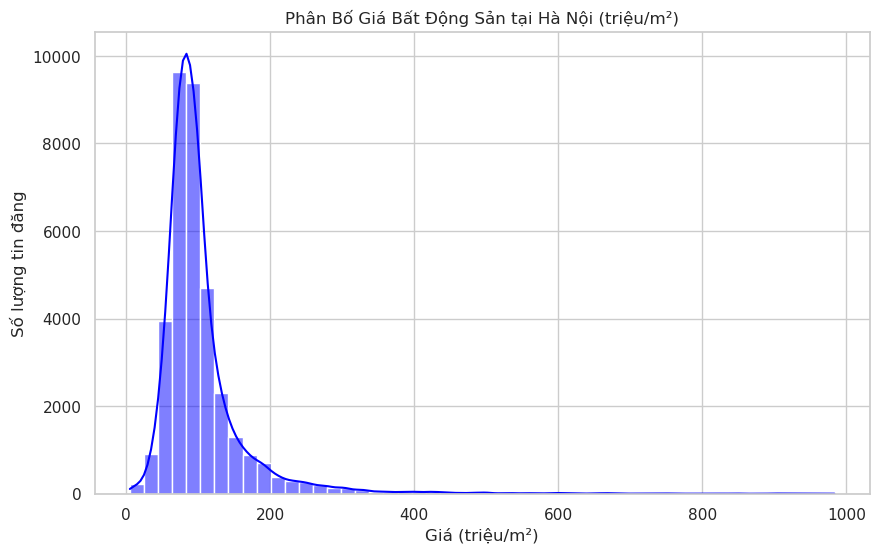

In [15]:
# ==========================================
# PHÂN TÍCH THEO 5 CÂU HỎI MỤC TIÊU
# ==========================================

print("\n=== KẾT QUẢ PHÂN TÍCH ===")

# --- CÂU 1: Phân bố giá bất động sản ---
plt.figure(figsize=(10, 6))
sns.histplot(df["Gia_Trieu_m2"], bins=50, kde=True, color="blue")
plt.title("Phân Bố Giá Bất Động Sản tại Hà Nội (triệu/m²)")
plt.xlabel("Giá (triệu/m²)")
plt.ylabel("Số lượng tin đăng")
plt.savefig("phan_bo_gia_bds.png")
print("\n[Câu 1] Phân bố giá bất động sản")
plt.show()

In [16]:
# --- CÂU 2: Quận/Huyện có giá trung bình cao nhất ---
gia_tb_quan = (
    df.groupby("Quận")["Gia_Trieu_m2"]
    .mean()
    .sort_values(ascending=False)
)
print("\n[Câu 2] Top 5 Quận/Huyện có giá BĐS trung bình cao nhất:")
print(gia_tb_quan.head(5))


[Câu 2] Top 5 Quận/Huyện có giá BĐS trung bình cao nhất:
Quận
Quận Hoàn Kiếm    277.978105
Quận Ba Đình      128.593109
Quận Cầu Giấy     126.443764
Quận Tây Hồ       123.202531
Quận Đống Đa      122.684958
Name: Gia_Trieu_m2, dtype: float64


In [4]:
# --- CÂU 3: Quận/Huyện có nhiều tin đăng nhất ---
tin_dang_quan = df["Quận"].value_counts()
print("\n[Câu 3] Top 5 Quận/Huyện có nhiều tin đăng nhất:")
print(tin_dang_quan.head(5))


[Câu 3] Top 5 Quận/Huyện có nhiều tin đăng nhất:
Quận
Quận Đống Đa         5775
Quận Thanh Xuân      5240
Quận Hoàng Mai       4604
Quận Hai Bà Trưng    3893
Quận Hà Đông         3884
Name: count, dtype: int64


In [5]:
# --- CÂU 4: Giá cao nhất, thấp nhất trong năm 2020 theo tháng ---
df_2020 = df[df["Nam"] == 2020]
gia_2020_theo_thang = df_2020.groupby("Thang")["Gia_Trieu_m2"].mean()

if not gia_2020_theo_thang.empty:
    thang_cao_nhat = gia_2020_theo_thang.idxmax()
    thang_thap_nhat = gia_2020_theo_thang.idxmin()
    print(
        f"\n[Câu 4] Trong năm 2020:\n"
        f"  - Tháng có giá TB cao nhất: Tháng {thang_cao_nhat} ({gia_2020_theo_thang[thang_cao_nhat]:.2f} triệu/m²)\n"
        f"  - Tháng có giá TB thấp nhất: Tháng {thang_thap_nhat} ({gia_2020_theo_thang[thang_thap_nhat]:.2f} triệu/m²)"
    )
else:
    print("\n[Câu 4] Không đủ dữ liệu năm 2020 sau khi lọc.")


[Câu 4] Trong năm 2020:
  - Tháng có giá TB cao nhất: Tháng 2 (200.00 triệu/m²)
  - Tháng có giá TB thấp nhất: Tháng 8 (96.85 triệu/m²)


In [14]:
# --- CÂU 5: Yếu tố ảnh hưởng lớn nhất ---

# 5.1. Ảnh hưởng của Vị trí (Quận) - Tính độ lệch giữa các vùng
bien_dong_vi_tri = (
    df.groupby("Quận")["Gia_Trieu_m2"].mean().std()
)  # Dùng độ lệch chuẩn để đo sự ảnh hưởng

# 5.2. Ảnh hưởng của Pháp lý
gia_theo_phap_ly = df.groupby("Giấy tờ pháp lý")["Gia_Trieu_m2"].mean()

# 5.3. Ảnh hưởng của Diện tích (Tính hệ số tương quan tuyến tính Pearson)
tuong_quan_dien_tich = df["Gia_Trieu_m2"].corr(df["Dien_Tich_Numeric"])

# --- 5.4. Ảnh hưởng của Loại hình nhà ở ---
gia_theo_loai_hinh = df.groupby("Loại hình nhà ở")["Gia_Trieu_m2"].mean()
bien_dong_loai_hinh = gia_theo_loai_hinh.std()

# --- 5.5. Ảnh hưởng của Số phòng ngủ ---
# Tính hệ số tương quan Pearson giữa Số phòng ngủ và Giá/m2
tuong_quan_phong_ngu = df["Gia_Trieu_m2"].corr(df["Phong_Ngu_Numeric"])

# --- 5.6. Ảnh hưởng của Số tầng ---
# Tính hệ số tương quan Pearson giữa Số tầng và Giá/m2
tuong_quan_so_tang = df["Gia_Trieu_m2"].corr(df["So_Tang_Numeric"])

# ------Kết quả phân tích--------
print("\n[Câu 5] Phân tích mức độ ảnh hưởng đến Giá/m2:")

print(
    f"\n  - Hệ số tương quan giữa Diện tích và Giá/m2: {tuong_quan_dien_tich:.4f}"
)

print("\n  - Giá trung bình theo Pháp lý:")
print(gia_theo_phap_ly)

print(
    f"\n  - Độ lệch chuẩn của giá giữa các Quận/Huyện: {bien_dong_vi_tri:.2f} triệu/m²"
)

print("\n  - Giá trung bình theo Loại hình nhà ở:")
print(gia_theo_loai_hinh.sort_values(ascending=False))
print(
    f"\n  - Độ lệch chuẩn giữa các loại hình nhà ở: {bien_dong_loai_hinh:.2f} triệu/m²"
)

print(
    f"\n  - Hệ số tương quan giữa Số phòng ngủ và Giá/m2: {tuong_quan_phong_ngu:.4f}"
)
# Để trực quan hơn, xem giá trung bình theo từng số lượng phòng ngủ cụ thể
print("\nGiá trung bình theo số lượng phòng ngủ (Top phổ biến):")
print(df.groupby("Phong_Ngu_Numeric")["Gia_Trieu_m2"].mean().head(6))

print(
    f"\n  - Hệ số tương quan giữa Số tầng và Giá/m2: {tuong_quan_so_tang:.4f}"
)
# Xem giá trung bình theo số tầng cụ thể
print("\nGiá trung bình theo số tầng (Top phổ biến):")
print(df.groupby("So_Tang_Numeric")["Gia_Trieu_m2"].mean().head(6))


[Câu 5] Phân tích mức độ ảnh hưởng đến Giá/m2:

  - Hệ số tương quan giữa Diện tích và Giá/m2: 0.1652

  - Giá trung bình theo Pháp lý:
Giấy tờ pháp lý
Chưa xác định     96.810286
Giấy tờ khác      76.150000
Đang chờ sổ       78.382553
Đã có sổ         104.759137
Name: Gia_Trieu_m2, dtype: float64

  - Độ lệch chuẩn của giá giữa các Quận/Huyện: 56.45 triệu/m²

  - Giá trung bình theo Loại hình nhà ở:
Loại hình nhà ở
Nhà mặt phố, mặt tiền    150.652416
Nhà biệt thự             130.100145
Nhà phố liền kề          117.211126
Nhà ngõ, hẻm              90.663772
Name: Gia_Trieu_m2, dtype: float64

  - Độ lệch chuẩn giữa các loại hình nhà ở: 25.11 triệu/m²

  - Hệ số tương quan giữa Số phòng ngủ và Giá/m2: 0.2713

Giá trung bình theo số lượng phòng ngủ (Top phổ biến):
Phong_Ngu_Numeric
1.0     89.520722
2.0     89.566875
3.0     92.982490
4.0    102.966586
5.0    117.289686
6.0    124.754693
Name: Gia_Trieu_m2, dtype: float64

  - Hệ số tương quan giữa Số tầng và Giá/m2: 0.3169

Giá trung b